In [1]:
# Cell 1: Data
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

# Your results
results = {
    "Model":        ["audio_only", "lyrics_only", "feature", "model", "decision", "cross_modal", "Chen et al. (baseline)"],
    "CCC Valence":  [0.0914,       0.3830,        0.2016,   0.1585,  0.2468,     0.0708,         0.15],
    "CCC Arousal":  [0.2182,       0.3291,        0.2780,   0.2449,  0.2462,     0.1406,         0.12],
    "PCC Valence":  [0.1635,       0.4341,        0.3794,   0.2588,  0.3624,     0.2747,         0.23],
    "PCC Arousal":  [0.4355,       0.3491,        0.3611,   0.2898,  0.3328,     0.3993,         0.17],
}

df = pd.DataFrame(results)

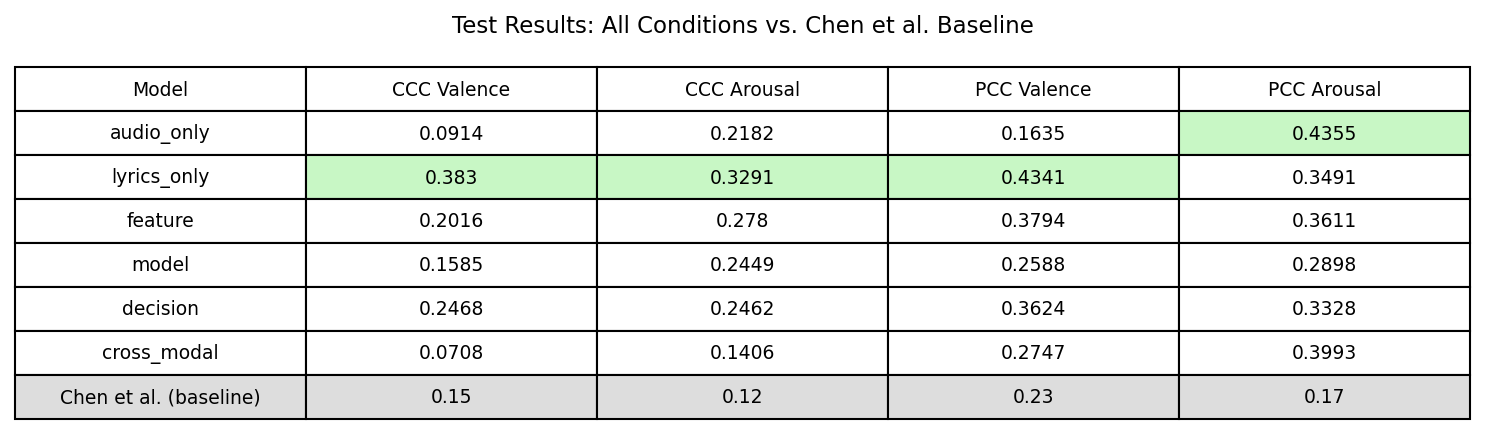

In [7]:
# Cell 2: Results table
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

# Highlight baseline row in light grey
for col in range(len(df.columns)):
    table[7, col].set_facecolor("#dddddd")

# Highlight best result per column in light green
for col_idx, col in enumerate(["CCC Valence", "CCC Arousal", "PCC Valence", "PCC Arousal"]):
    best_row = df[col].iloc[:6].idxmax() + 1  # +1 for header offset
    table[best_row, col_idx + 1].set_facecolor("#c8f7c5")

plt.title("Test Results: All Conditions vs. Chen et al. Baseline", fontsize=11, pad=20)
plt.tight_layout()
plt.show()

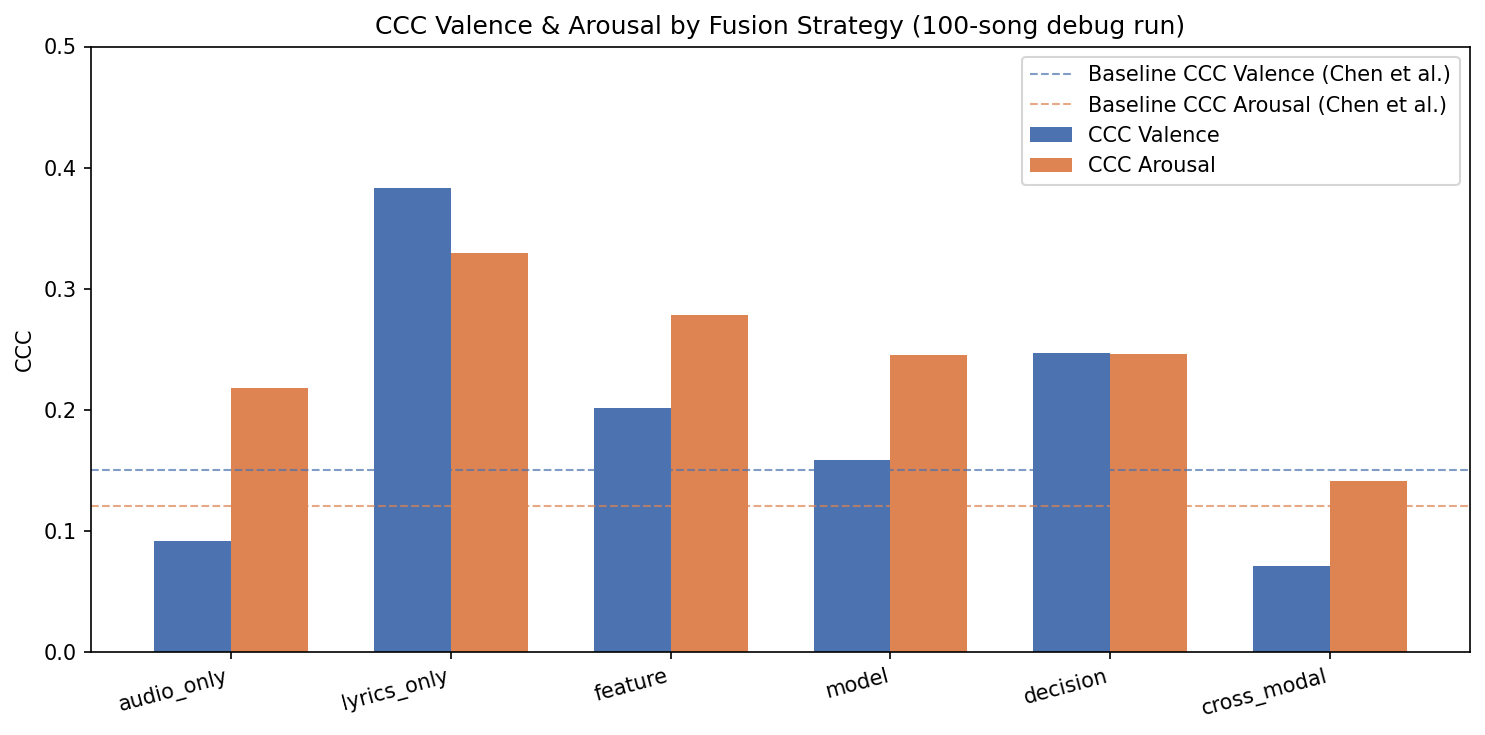

In [6]:
# Cell 3: Bar chart
conditions = ["audio_only", "lyrics_only", "feature", "model", "decision", "cross_modal"]
ccc_valence = [0.0914, 0.3830, 0.2016, 0.1585, 0.2468, 0.0708]
ccc_arousal = [0.2182, 0.3291, 0.2780, 0.2449, 0.2462, 0.1406]

x = range(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], ccc_valence, width, label="CCC Valence", color="#4C72B0")
bars2 = ax.bar([i + width/2 for i in x], ccc_arousal, width, label="CCC Arousal", color="#DD8452")

# Baseline reference lines
ax.axhline(y=0.15, color="#4C72B0", linestyle="--", linewidth=1, alpha=0.7, label="Baseline CCC Valence (Chen et al.)")
ax.axhline(y=0.12, color="#DD8452", linestyle="--", linewidth=1, alpha=0.7, label="Baseline CCC Arousal (Chen et al.)")

ax.set_xticks(list(x))
ax.set_xticklabels(conditions, rotation=15, ha="right")
ax.set_ylabel("CCC")
ax.set_title("CCC Valence & Arousal by Fusion Strategy (100-song debug run)")
ax.legend()
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.show()

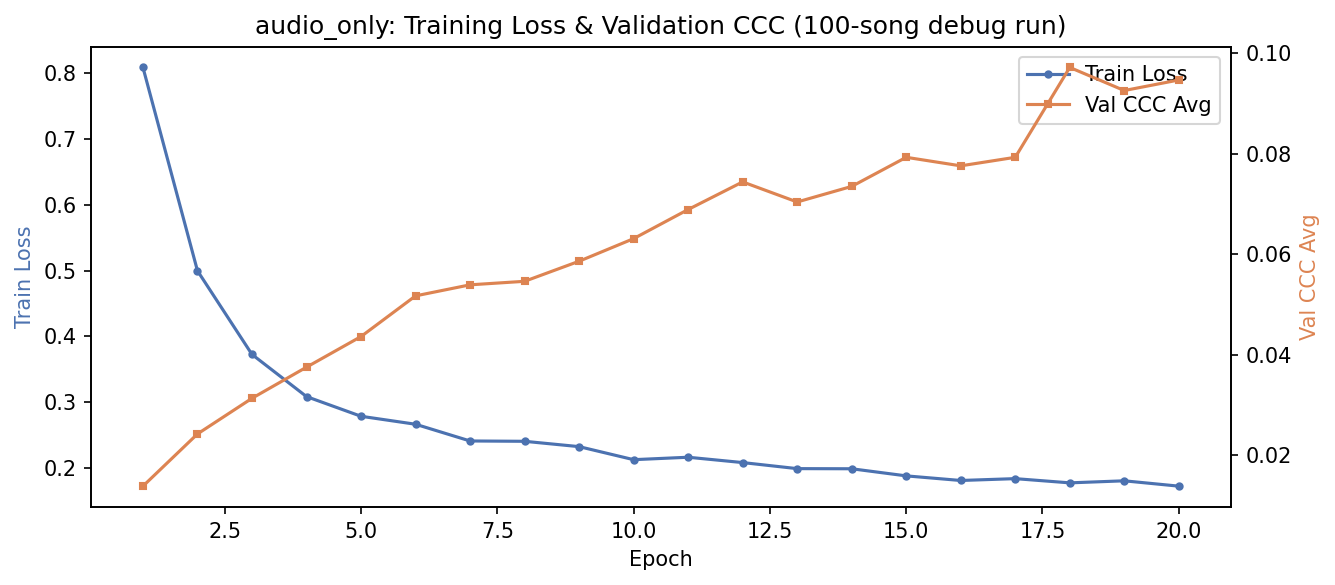

In [9]:
# Cell 4: Training loss curve (audio_only, 20 epochs)
epochs = list(range(1, 21))
train_loss = [
    0.8084, 0.4996, 0.3726, 0.3086, 0.2787,
    0.2666, 0.2412, 0.2407, 0.2326, 0.2128,
    0.2165, 0.2084, 0.1992, 0.1990, 0.1882,
    0.1812, 0.1840, 0.1776, 0.1807, 0.1726,
]
val_ccc_avg = [
    0.0138, 0.0242, 0.0313, 0.0375, 0.0436,
    0.0517, 0.0539, 0.0546, 0.0586, 0.0631,
    0.0689, 0.0744, 0.0704, 0.0735, 0.0793,
    0.0776, 0.0793, 0.0972, 0.0926, 0.0947,
]

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.plot(epochs, train_loss, color="#4C72B0", marker="o", markersize=3, label="Train Loss")
ax2.plot(epochs, val_ccc_avg, color="#DD8452", marker="s", markersize=3, label="Val CCC Avg")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color="#4C72B0")
ax2.set_ylabel("Val CCC Avg", color="#DD8452")
ax1.set_title("audio_only: Training Loss & Validation CCC (100-song debug run)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

In [10]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/

Mounted at /content/drive
/content/drive/MyDrive


In [11]:
%cd /content/drive/MyDrive/MER_Multimodal_Fusion

/content/drive/MyDrive/MER_Multimodal_Fusion


In [12]:
%%bash
cat > /content/drive/MyDrive/MER_Multimodal_Fusion/.gitignore << 'EOF'
data/raw/
data/processed/
logs/
__pycache__/
*.pyc
.ipynb_checkpoints/
*.pt
EOF

In [ ]:
%%bash
cd /content/drive/MyDrive/MER_Multimodal_Fusion
git add .
git status  # check what's being staged before committing